# Real-Time Bitcoin API Integration with DocsGPT

This notebook demonstrates the integration of the CoinGecko API for real-time Bitcoin price retrieval and analysis. It compares direct API calls with a Python wrapper, stores results in a CSV file, and visualizes price trends. The goal is to create a reusable API interface for further time series analysis and question-answering pipelines powered by DocsGPT.

## Description

- Fetches real-time Bitcoin price data using the CoinGecko API.
- Compares raw API calls to a Python wrapper function (`fetch_bitcoin_price`).
- Stores each price point with timestamps in a CSV file.
- Updates and loads datasets for persistence and reusability.
- Computes log returns and volatility using `pandas`.
- Visualizes price and volatility trends using `matplotlib`.
- Analyzes historical trends and identifies anomalies (e.g., volatility spikes).
- Prepares the dataset for downstream usage in LLM-powered Q&A bots.

## References

- [`BitcoinLLMQA.API.md`](./BitcoinLLMQA.API.md) – API wrapper documentation.
- [`BitcoinLLMQA_utils.py`](./BitcoinLLMQA_utils.py) – Utility functions for API access, analysis, and visualization.
- [`BitcoinLLMQA.example.ipynb`](./BitcoinLLMQA.example.ipynb) – Interactive Q&A demonstration using this dataset.
- [Jupyter Notebook Style Guide](https://github.com/causify-ai/helpers/blob/master/docs/coding/all.jupyter_notebook.how_to_guide.md)

## Citation

- CoinGecko API: https://www.coingecko.com/en/api
- DocsGPT: https://github.com/arc53/DocsGPT

## Notebook Naming Convention

This notebook follows the naming format for API-related projects:

BitcoinLLMQA.API.ipynb

## Initial Setup

In [1]:
from BitcoinLLMQA_utils import (
    fetch_bitcoin_price,
    update_dataset,
    analyze_data,
    load_dataset,
    visualize_bitcoin_data,
    get_price_trends
)

import pandas as pd
import matplotlib.pyplot as plt
import requests

## Demonstrate CoinGecko API (Raw vs Wrapper)

In [2]:
response = requests.get("https://api.coingecko.com/api/v3/simple/price?ids=bitcoin&vs_currencies=usd", timeout=10)
raw_data = response.json()
print("Direct CoinGecko API call:")
print(f"Response: {raw_data}")
print(f"Bitcoin price: ${raw_data['bitcoin']['usd']:,.2f}\n")

# Show wrapper function
print("Using our wrapper function:")
btc_price = fetch_bitcoin_price()
print(f"Bitcoin price: ${btc_price:,.2f}")

Direct CoinGecko API call:
Response: {'bitcoin': {'usd': 103656}}
Bitcoin price: $103,656.00

Using our wrapper function:
Bitcoin price: $103,656.00


# Demonstrate dataset update

In [3]:
print("Updating dataset with current price...")
df = update_dataset(btc_price)
print("\nMost recent entries:")
display(df.tail(5))

Updating dataset with current price...
Saved price: 103656 | Volatility: 0.24684912485507832

Most recent entries:


,timestamp,price,volatility,log_returns
1147,2025-05-09 21:02:00,29462.48,0.231241,0.033465
1148,2025-05-09 21:07:00,31400.39,0.236622,0.063703
1149,2025-05-09 21:12:00,29095.85,0.239118,-0.076225
1150,2025-05-09 21:17:00,31924.06,0.254599,0.092764
1151,2025-05-09 21:22:00,29738.55,0.246849,-0.070916


# Load and visualize historical data

Loading complete dataset...
Dataset contains 1152 records


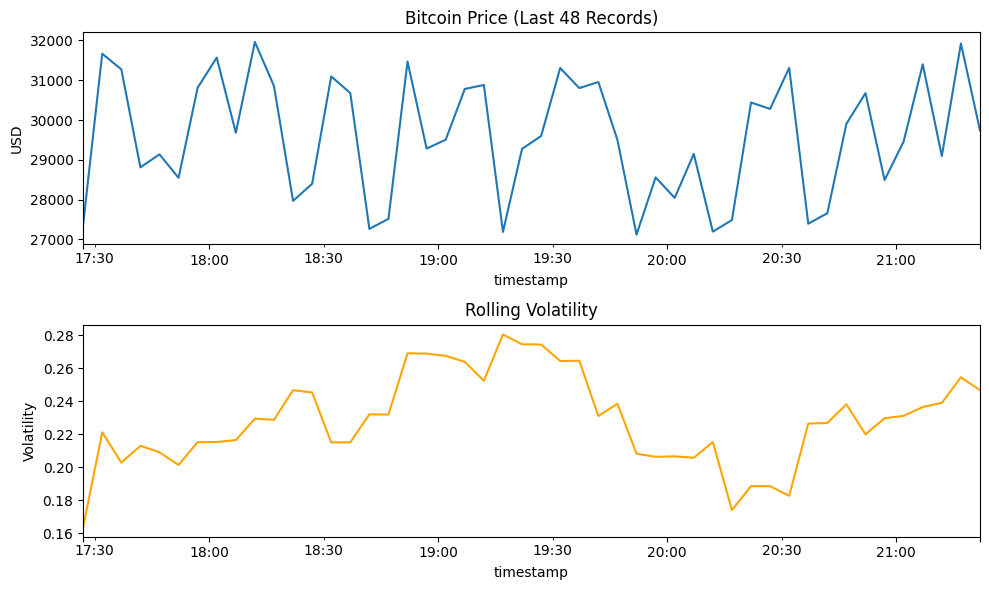

In [4]:
print("Loading complete dataset...")
complete_df = load_dataset()
print(f"Dataset contains {len(complete_df)} records")

# Generate visualization
fig = visualize_bitcoin_data(complete_df)
plt.show()

# Demonstrate analysis functions

In [5]:
# Get price trend analysis
print("Price trends:")
trends = get_price_trends(complete_df, period='24h')
for key, value in trends.items():
    if key == 'pct_change':
        print(f"{key}: {value:.2f}%")
    elif 'price' in key:
        print(f"{key}: ${value:,.2f}")
    else:
        print(f"{key}: {value}")

# Generate metrics
print("\nGenerating dataset metrics...")
metrics = analyze_data(complete_df)

print("\nHourly averages:")
display(metrics['hourly_avg'].tail(3))

print("\nVolatility anomalies:")
if len(metrics['recent_anomalies']) > 0:
    display(metrics['recent_anomalies'].tail(3))
else:
    print("No recent volatility anomalies detected")

Price trends:
error: Not enough data points for the selected period

Generating dataset metrics...

Hourly averages:


,price,volatility,log_returns
timestamp,,,
2025-05-09 19:00:00,29623.299167,0.252296,-0.002084
2025-05-09 20:00:00,29003.483333,0.208645,-0.000196
2025-05-09 21:00:00,30324.266000,0.241686,0.008558



Volatility anomalies:


,timestamp,price,volatility,log_returns
918,2025-05-09 01:57:00,28888.03,0.349570,-0.080106
919,2025-05-09 02:02:00,30783.77,0.353286,0.063560
920,2025-05-09 02:07:00,30540.07,0.353697,-0.007948


# Summary

In [6]:
print("\nAPI Integration Summary:")
print("1. CoinGecko API provides real-time Bitcoin price data")
print("2. Our wrapper functions simplify data fetching, storage and analysis")
print("3. Datasets are stored with timestamps in CSV format")
print("4. Advanced metrics include volatility calculation and anomaly detection")


API Integration Summary:
1. CoinGecko API provides real-time Bitcoin price data
2. Our wrapper functions simplify data fetching, storage and analysis
3. Datasets are stored with timestamps in CSV format
4. Advanced metrics include volatility calculation and anomaly detection
